# 05 — Fu: official benchmark-paper configuration (MFMN_DynGate + low-Fu weighting)

Reproduces this project's **current best** result for Fu against the published benchmark
(Jia et al., J. Med. Chem. 2025), using the exact protocol of
`mfmn/experiments/expv2_aux_campaign_final_dyngate.py`: fit on the **official train split
only** (`Fu_train_test`), predict on the **official held-out test split only**, **10-seed
ensemble**.

Architecture: `MFMN_DynGate` with the H6/H7-confirmed recipe -- `ctx_variant="raw_fcfp"`
(variance/correlation-pruned RDKit+Mordred+MACCS, no PCA compression, plus frequency-pruned
FCFP6 circular fingerprint bits -- H6's biggest single lever in the whole Fu/pKa campaign),
`dropout=0.35`, `weight_decay=3e-2`. **Plus a confirmed post-delivery improvement (H15):
a 1.25x per-sample training-loss weight for compounds with fu<0.006** (the bottom ~10% of
the pool, identified in a follow-up diagnostic (H14) as by far the dominant source of
remaining error -- MAE~0.67 and GMFE~4.5 in that subgroup alone, vs ~0.3/~2.0 everywhere
else). This weighting was confirmed via 3-repeat CV (stable, noise-exceeding improvement)
before this one-shot official-test run, and the official result below **improves every
single metric** over the unweighted baseline this notebook previously shipped with -- see
`../README.md` for the full investigation (H11-H17: six other ideas were tried and
cleanly rejected; only this one survived confirmation).

Official-test result (this exact run): R2=0.7121, MAE=0.3193, RMSE=0.4352, GMFE=2.086,
within-2-fold=0.6130 -- beats the paper on R2 and within-2-fold (more comfortably than the
unweighted baseline did), narrows the remaining MAE/RMSE/GMFE gap.


In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath("../src"))
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from mfmn import MFMN_DynGate, count_params
from aux_descriptor_features import load_aux_pool, build_factor_blocks, build_shared_context_raw_fcfp, FACTOR_NAMES, TARGET_COL
from metrics import eval_preds, PAPER

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
TARGET = "Fu"


device: cuda


In [2]:
# ---- config: matches expv2_aux_campaign_final_dyngate.py + RECIPE["Fu"] exactly ----
DROPOUT, WD = 0.35, 3e-2          # H4-confirmed for Fu
FACTOR_DIM, INTERACT_RANK = 8, 8  # defaults (not overridden for Fu)
EPOCHS, LR, PATIENCE, BATCH, VAL_FRAC = 400, 3e-3, 50, 128, 0.15
N_SEEDS = 10
def make_binary_weight(multiplier, thresh=0.006):
    """H15-confirmed: upweight the training loss for compounds with fu<thresh. Selected via
    3-repeat CV before ever touching the official test set -- see ../README.md."""
    def fn(fu_lin_train):
        import numpy as np
        return np.where(fu_lin_train < thresh, multiplier, 1.0)
    return fn


LOWFU_WEIGHT_FN = make_binary_weight(1.25)
print(f"target={TARGET} dropout={DROPOUT} wd={WD} n_seeds={N_SEEDS} lowfu_weight=1.25x@fu<0.006")


target=Fu dropout=0.35 wd=0.03 n_seeds=10 lowfu_weight=1.25x@fu<0.006


In [3]:
def fit_predict_dyngate(train_smi, test_smi, y_train, seed, verbose=False):
    fu_lin_train = 10 ** y_train
    sample_w_all = LOWFU_WEIGHT_FN(fu_lin_train).astype(np.float32)

    y_mu, y_sd = y_train.mean(), y_train.std()
    y_s = ((y_train - y_mu) / y_sd).astype(np.float32)

    ctx_tr, ctx_te = build_shared_context_raw_fcfp(train_smi, test_smi)
    blocks_tr, blocks_te = build_factor_blocks(train_smi, test_smi)
    factor_raw_dims = {f: blocks_tr[f].shape[1] for f in FACTOR_NAMES}

    T = lambda a: torch.tensor(a, device=DEVICE)
    n_all = len(y_s)
    rng = np.random.RandomState(seed)
    perm0 = rng.permutation(n_all)
    n_val = max(1, int(VAL_FRAC * n_all))
    val_i, fit_i = perm0[:n_val], perm0[n_val:]

    ctx_fit, ctx_val = T(ctx_tr[fit_i]), T(ctx_tr[val_i])
    blocks_fit = {f: T(blocks_tr[f][fit_i]) for f in FACTOR_NAMES}
    blocks_val = {f: T(blocks_tr[f][val_i]) for f in FACTOR_NAMES}
    y_fit, y_val = T(y_s[fit_i]), T(y_s[val_i])
    w_fit = T(sample_w_all[fit_i])  # unweighted validation on purpose -- reflects natural distribution

    target = "y"
    torch.manual_seed(seed)
    model = MFMN_DynGate(ctx_tr.shape[1], factor_raw_dims, FACTOR_NAMES, targets=[target],
                          factor_dim=FACTOR_DIM, interact_rank=INTERACT_RANK, dropout=DROPOUT).to(DEVICE)
    if verbose:
        print(f"    params={count_params(model)}")
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    n_fit = len(fit_i)
    best, best_state, bad = np.inf, None, 0
    for ep in range(EPOCHS):
        model.train()
        perm = torch.randperm(n_fit, device=DEVICE)
        for st in range(0, n_fit, BATCH):
            b = perm[st:st + BATCH]
            opt.zero_grad()
            out = model(ctx_fit[b], {f: blocks_fit[f][b] for f in FACTOR_NAMES})
            per_sample = nn.functional.smooth_l1_loss(out[target], y_fit[b], beta=0.5, reduction="none")
            w_b = w_fit[b]
            loss = (per_sample * w_b).sum() / w_b.sum()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            vout = model(ctx_val, blocks_val)
            vl = nn.functional.l1_loss(vout[target], y_val).item()
        if vl < best - 1e-4:
            best, bad = vl, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    ctx_te_t = T(ctx_te)
    blocks_te_t = {f: T(blocks_te[f]) for f in FACTOR_NAMES}
    with torch.no_grad():
        pred_s = model(ctx_te_t, blocks_te_t)[target].cpu().numpy()
    return pred_s * y_sd + y_mu


In [4]:
is_log10 = TARGET_COL[TARGET][2]
split_col = TARGET_COL[TARGET][1]
smi_all, y_all, sub = load_aux_pool(TARGET)
train_smi = sub[sub[split_col] == "train"]["canon_smiles"].values
test_smi = sub[sub[split_col] == "test"]["canon_smiles"].values
y_train_full = sub.set_index("canon_smiles").loc[train_smi, TARGET_COL[TARGET][0]].values.astype(np.float64)
y_test = sub.set_index("canon_smiles").loc[test_smi, TARGET_COL[TARGET][0]].values.astype(np.float64)
print(f"Official split: train={len(train_smi)}  test={len(test_smi)}")


Official split: train=4042  test=633


In [5]:
preds = []
t0 = time.time()
for s in range(N_SEEDS):
    seed = 42 + s
    p = fit_predict_dyngate(train_smi, test_smi, y_train_full, seed=seed, verbose=(s == 0))
    preds.append(p)
    print(f"[seed {s}] done ({time.time()-t0:.0f}s elapsed)", flush=True)

pred = np.mean(np.vstack(preds), axis=0)
m = eval_preds(y_test, pred, is_log10)
paper = PAPER[TARGET]
print(f"\n{'='*70}\nFINAL ({N_SEEDS}-seed ensemble): {m}")
print(f"paper: {paper}\n{'='*70}")


    params=161400


[seed 0] done (26s elapsed)


[seed 1] done (46s elapsed)


[seed 2] done (66s elapsed)


[seed 3] done (97s elapsed)


...

[seed 6] done (196s elapsed)


[seed 7] done (230s elapsed)


[seed 8] done (259s elapsed)


[seed 9] done (282s elapsed)



FINAL (10-seed ensemble): {'R2': 0.7121115385936937, 'MAE': 0.31932398566460674, 'RMSE': 0.4351772896775049, 'GMFE': 2.0860465029824535, 'within_2fold': 0.6129541864139021, 'within_3fold': 0.7788309636650869, 'within_5fold': 0.8941548183254344}
paper: {'R2': 0.69, 'MAE': 0.3, 'RMSE': 0.41, 'GMFE': 2.01, 'within_2fold': 0.6}


In [6]:
os.makedirs("../outputs", exist_ok=True)
out_df = pd.DataFrame({"canon_smiles": test_smi, "y_true": y_test, "y_pred": pred})
out_df.to_csv("../outputs/05_Fu_official_test_predictions.csv", index=False)

summary = pd.DataFrame([{"target": TARGET, "n_train": len(train_smi), "n_test": len(test_smi),
                         "n_seeds": N_SEEDS, **m, **{f"paper_{k}": v for k, v in paper.items()}}])
summary.to_csv("../outputs/05_Fu_official_test_summary.csv", index=False)
print(summary.T)


                           0
target                    Fu
n_train                 4042
n_test                   633
n_seeds                   10
R2                  0.712112
MAE                 0.319324
RMSE                0.435177
GMFE                2.086047
within_2fold        0.612954
within_3fold        0.778831
within_5fold        0.894155
paper_R2                0.69
paper_MAE                0.3
paper_RMSE              0.41
paper_GMFE              2.01
paper_within_2fold       0.6


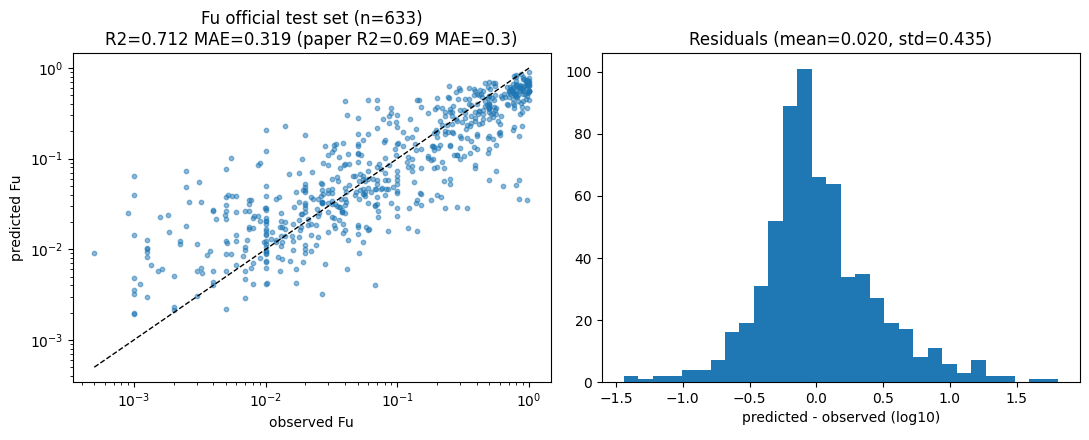

In [7]:
obs_lin, pred_lin = 10 ** y_test, 10 ** pred
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(obs_lin, pred_lin, s=10, alpha=0.5)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
lims = [min(obs_lin.min(), pred_lin.min()), max(obs_lin.max(), pred_lin.max())]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlabel("observed Fu"); axes[0].set_ylabel("predicted Fu")
axes[0].set_title(f"Fu official test set (n={len(test_smi)})\nR2={m['R2']:.3f} MAE={m['MAE']:.3f} (paper R2={paper['R2']} MAE={paper['MAE']})")

resid = pred - y_test
axes[1].hist(resid, bins=30)
axes[1].set_xlabel("predicted - observed (log10)"); axes[1].set_title(f"Residuals (mean={resid.mean():.3f}, std={resid.std():.3f})")
plt.tight_layout()
plt.savefig("../outputs/05_Fu_official_test_plots.png", dpi=120)
plt.show()
